In [1]:
import numpy as np
import xarray as xr
import csv
import pandas as pd
import os
import netCDF4 as nc4
import sys

import functions_py.fates_xarray_functions as fa

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from matplotlib import cm
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm
from mpl_toolkits.mplot3d import Axes3D

from shapely.geometry import Polygon

/global/homes/j/jneedham/.conda/envs/myenv/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
fates = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/PA_mine_phase.Ea435e8dd8c-Fea425ee7.2025-05-22/run/PA_mine_phase.Ea435e8dd8c-Fea425ee7.2025-05-22.sofar.nc'
fates = xr.open_dataset(fates, decode_times=False)

#fates_log = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/PA_logging-mine_phase.Ea8fbc2fc28-F7aa80c14.2025-06-02/run/PA_logging-mine_phase.Ea8fbc2fc28-F7aa80c14.2025-06-02.sofar.nc'
#fates_log = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/PA_logging-mine_phase.Ea8fbc2fc28-F7aa80c14.2025-06-04/run/PA_logging-mine_phase.Ea8fbc2fc28-F7aa80c14.2025-06-04.sofar.nc'
fates_log  = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/PA_logging-mine_phase.Ea8fbc2fc28-F7aa80c14.2025-06-06/run/PA_logging-mine_phase.Ea8fbc2fc28-F7aa80c14.2025-06-06.sofar.nc'
fates_log = xr.open_dataset(fates_log, decode_times=False)


In [3]:
nyears = int(len(fates.variables['time'])/12)
print(nyears)
#time = np.arange(0,nyears*12,1) / 12
time = fates.variables['time'] / 365.

nyears_log = int(len(fates_log.variables['time'])/12)
print(nyears_log)
#time_log = np.arange(0,nyears_log*12,1) / 12
time_log = fates_log.variables['time'] / 365.

tave_start = (nyears*12-20*12)
tave_stop = nyears*12

cohort_size_bins = fates.variables['fates_levscls'][:]
nsizebins = len(cohort_size_bins)
patch_age_bins = fates.variables['fates_levage'][:]

42
70


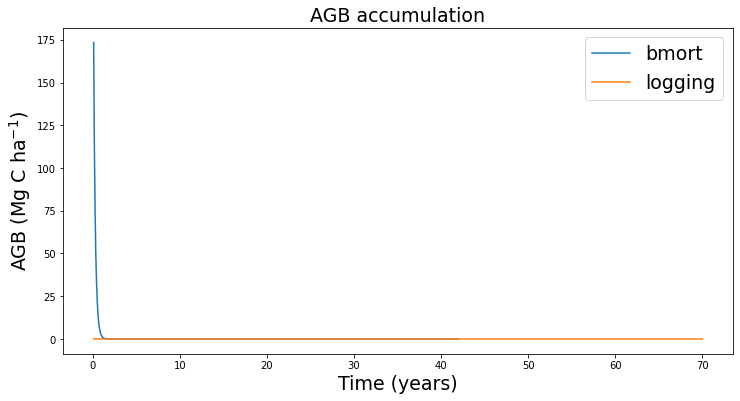

In [4]:
AGB = fates.FATES_VEGC_ABOVEGROUND_SZPF  * 10000 * 0.001 * 2
AGB = AGB.sum(dim='fates_levscpf')

AGB_log = fates_log.FATES_VEGC_ABOVEGROUND_SZPF  * 10000 * 0.001 * 2
AGB_log = AGB_log.sum(dim='fates_levscpf')

fig1, ((f1ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(12,6))

f1ax0.plot(time, AGB,  label = 'bmort') 
f1ax0.plot(time_log, AGB_log, label = 'logging') 
f1ax0.set_title(r'AGB accumulation', fontsize = 19)
f1ax0.set_ylabel(r'AGB (Mg C ha$^{-1}$)', fontsize = 19)
f1ax0.set_xlabel(r'Time (years)', fontsize = 19)    
f1ax0.legend(fontsize=19)

###   Soil carbon

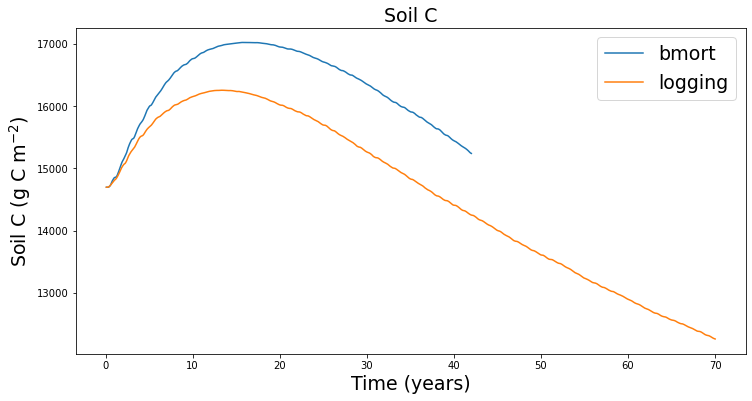

In [5]:
soilC = fates.SOILC 

soilC_log = fates_log.SOILC 

fig1, ((f1ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(12,6))

f1ax0.plot(time, soilC, label = 'bmort')    
f1ax0.plot(time_log, soilC_log, label = 'logging')    
f1ax0.set_title(r'Soil C', fontsize = 19)
f1ax0.set_ylabel(r'Soil C (g C m$^{-2}$)', fontsize = 19)
f1ax0.set_xlabel(r'Time (years)', fontsize = 19)  
f1ax0.legend(fontsize=19)

## Where is this carbon coming from?!?!?!

### Recruitment 

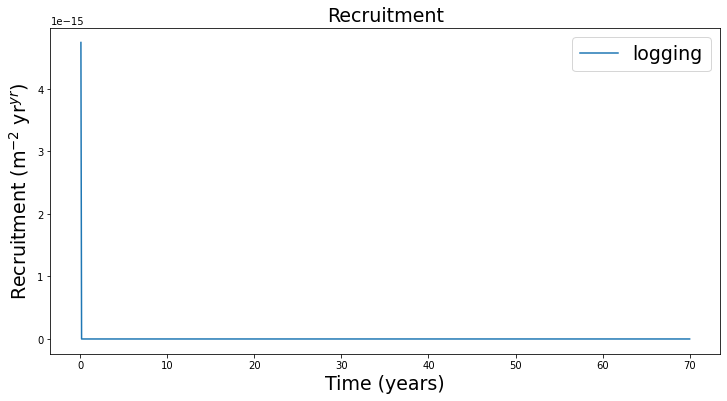

In [6]:
recr = fates_log.FATES_RECRUITMENT_PF.sum(dim='fates_levpft')

fig1, ((f1ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(12,6))

f1ax0.plot(time_log, recr, label = 'logging') 
f1ax0.set_title(r'Recruitment', fontsize = 19)
f1ax0.set_ylabel(r'Recruitment (m$^{-2}$ yr$^{yr}$)', fontsize = 19)
f1ax0.set_xlabel(r'Time (years)', fontsize = 19)    
f1ax0.legend(fontsize=19)

### Survivors?

Text(0.5, 0, 'Time (years)')

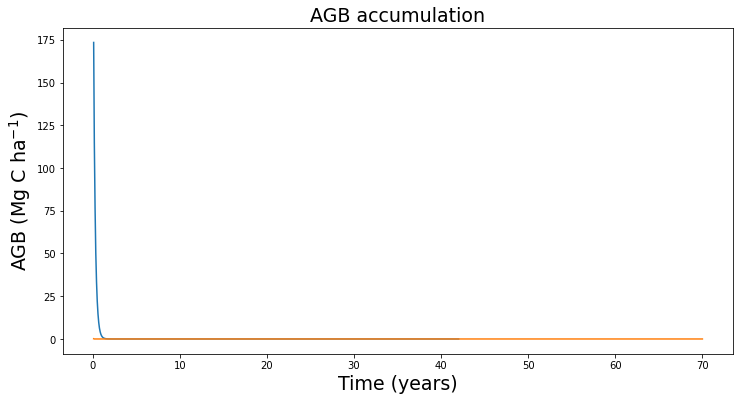

In [7]:
fig1, ((f1ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(12,6))

f1ax0.plot(time, AGB, label = 'bmort') 
f1ax0.plot(time_log, AGB_log, label = 'logging') 
f1ax0.set_title(r'AGB accumulation', fontsize = 19)
f1ax0.set_ylabel(r'AGB (Mg C ha$^{-1}$)', fontsize = 19)
f1ax0.set_xlabel(r'Time (years)', fontsize = 19)    
#f1ax0.set_ylim(0,5)
#f1ax0.set_xlim(0,5)

### So not everything is dying? 

Text(0.5, 0, 'Time (years)')

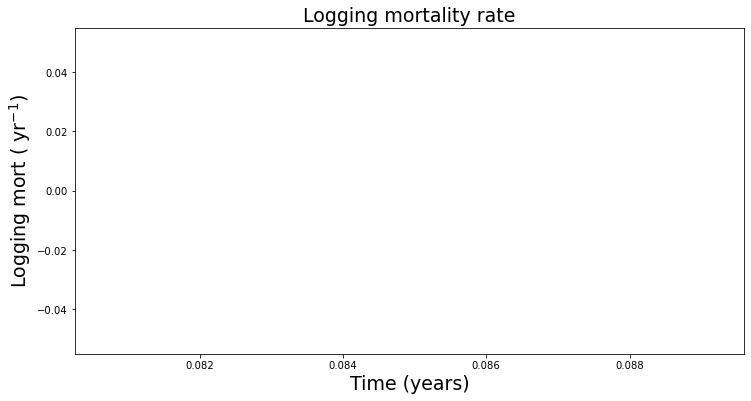

In [8]:
logging_mort = fates_log.FATES_MORTALITY_LOGGING_SZ.sum(dim='fates_levscls')
nplant = fates_log.FATES_NPLANT_SZ.sum(dim='fates_levscls')

logging_mort = logging_mort/nplant

fig1, ((f1ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(12,6))

f1ax0.plot(time_log, logging_mort, label = 'logging') 
f1ax0.set_title(r'Logging mortality rate', fontsize = 19)
f1ax0.set_ylabel(r'Logging mort ( yr$^{-1}$)', fontsize = 19)
f1ax0.set_xlabel(r'Time (years)', fontsize = 19)    
#f1ax0.set_ylim(0,1)
#f1ax0.set_xlim(0,1)

#### why is this 0? 

### Disturbance rate

(0.0, 10.0)

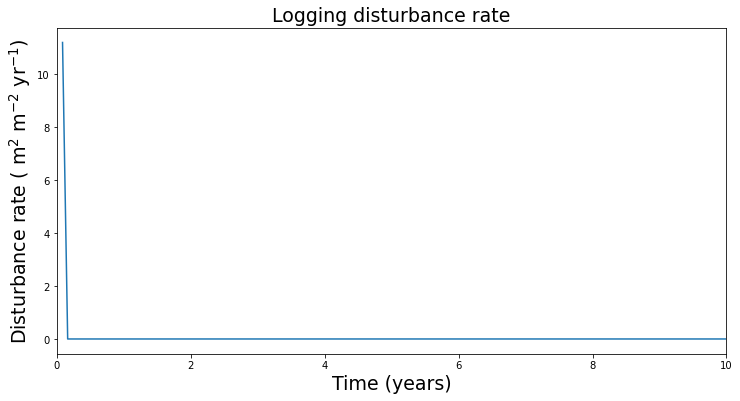

In [9]:
dist_rate = fates_log.FATES_DISTURBANCE_RATE_LOGGING

fig1, ((f1ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(12,6))

f1ax0.plot(time_log, dist_rate, label = 'logging') 
f1ax0.set_title(r'Logging disturbance rate', fontsize = 19)
f1ax0.set_ylabel(r'Disturbance rate ( m$^{2}$ m$^{-2}$ yr$^{-1}$)', fontsize = 19)
f1ax0.set_xlabel(r'Time (years)', fontsize = 19)    
#f1ax0.set_ylim(0,1)
f1ax0.set_xlim(0,10)

### Number of plants

(0.0, 0.02)

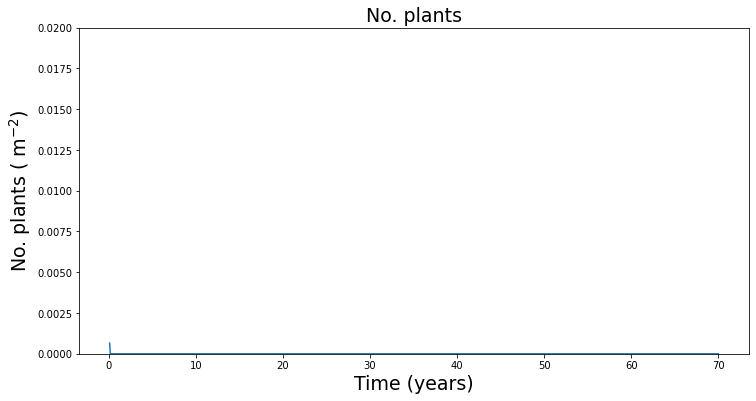

In [10]:
nplant = fates_log.FATES_NPLANT_SZ.sum(dim='fates_levscls')


fig1, ((f1ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(12,6))

f1ax0.plot(time_log, nplant, label = 'logging') 
f1ax0.set_title(r'No. plants', fontsize = 19)
f1ax0.set_ylabel(r'No. plants ( m$^{-2}$)', fontsize = 19)
f1ax0.set_xlabel(r'Time (years)', fontsize = 19)    
f1ax0.set_ylim(0,0.02)
#f1ax0.set_xlim(0,1)